In [2]:
import pandas as pd

df = pd.read_csv("../data/processed_energy_hourly.csv")
df.head()

,datetime,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
1,2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2,2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
3,2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
4,2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667


In [3]:
print(df.shape)
print(df.columns)
df.info()

(34589, 8)
Index(['datetime', 'Global_active_power', 'Global_reactive_power', 'Voltage',
       'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 34589 entries, 0 to 34588
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   datetime               34589 non-null  str    
 1   Global_active_power    34589 non-null  float64
 2   Global_reactive_power  34589 non-null  float64
 3   Voltage                34589 non-null  float64
 4   Global_intensity       34589 non-null  float64
 5   Sub_metering_1         34589 non-null  float64
 6   Sub_metering_2         34589 non-null  float64
 7   Sub_metering_3         34589 non-null  float64
dtypes: float64(7), str(1)
memory usage: 2.1 MB


In [4]:
df.describe()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,34589.000000,34589.000000,34589.000000,34589.000000,34589.000000,34589.000000,34589.000000
mean,1.086200,0.123326,240.841505,4.604360,1.110951,1.287914,6.416515
std,0.894942,0.067221,2.999127,3.746337,3.518498,4.168720,7.344718
min,0.124000,0.000000,225.834500,0.503333,0.000000,0.000000,0.000000
25%,0.341267,0.077667,239.197167,1.510000,0.000000,0.000000,0.650000
50%,0.799533,0.106767,240.984500,3.406667,0.000000,0.333333,1.650000
75%,1.574967,0.149367,242.691833,6.583333,0.000000,0.650000,14.083333
max,6.560533,0.774333,251.902000,28.383333,48.366667,46.433333,21.550000


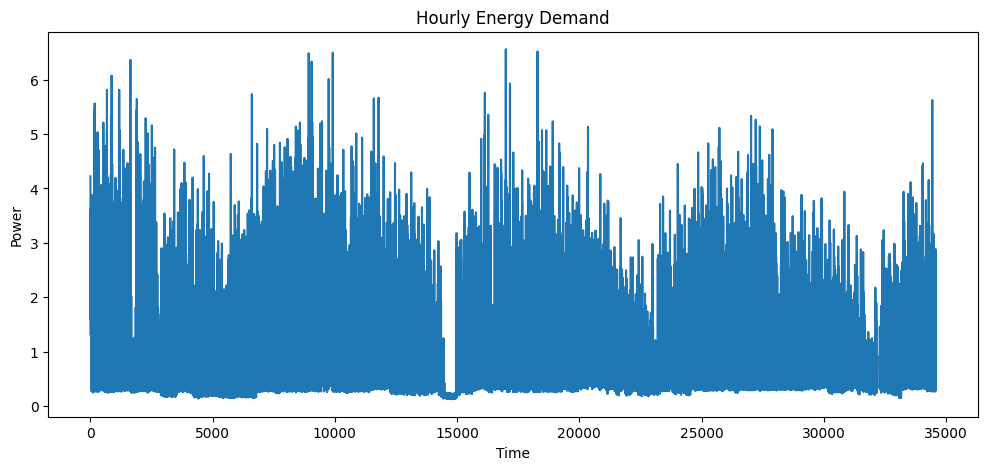

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df["Global_active_power"])
plt.title("Hourly Energy Demand")
plt.xlabel("Time")
plt.ylabel("Power")
plt.show()

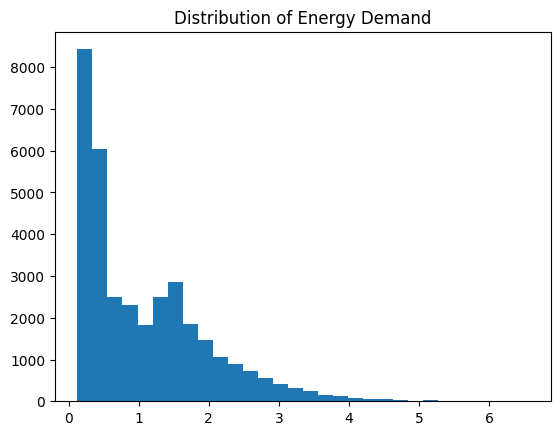

In [6]:
plt.hist(df["Global_active_power"], bins=30)
plt.title("Distribution of Energy Demand")
plt.show()

In [7]:
df.isnull().sum()

datetime                 0
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# create lag feature
df["lag1"] = df["Global_active_power"].shift(1)

# remove missing values
df = df.dropna()

# features and target
X = df[["lag1"]]
y = df["Global_active_power"]

# split (80% train, 20% test)
split = int(len(df) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# train model
model = LinearRegression()
model.fit(X_train, y_train)

# predict
y_pred = model.predict(X_test)

# evaluate
mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 0.39253607223715575


In [9]:
n = len(df)

train_end = int(n * 0.7)
val_end = int(n * 0.85)

train = df[:train_end]
val = df[train_end:val_end]
test = df[val_end:]

print("Train:", len(train))
print("Val:", len(val))
print("Test:", len(test))

Train: 24211
Val: 5188
Test: 5189
